# Global Setup

## Imports

Base imports for initial pandas dataframe and plotting

In [8]:
import re
import random
import time
from collections import Counter
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Base imports for SKLearn packages, used in data split and error analysis

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Base imports for CNN

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import torch.nn.functional as F


Base imports for distilBERT

In [11]:
from datasets import Dataset as HFDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

## Other parameters

Setting seeds to make results reproducable

In [12]:
def set_seed(seed: int = 42) -> None:
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

Setting the device to use the GPU if available for faster training and fine tuning

In [13]:
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("Using CPU")
    device = torch.device("cpu")
device

Using GPU: NVIDIA GeForce RTX 3060


device(type='cuda')

## Data Preprocessing

importing data

In [14]:
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}

init_train_df = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["train"], lines=True)
init_test_df = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["test"], lines=True)

Filtering links from text and updating labels to run from 0-3 instead of 1-4

In [15]:
init_train_df['description'] = init_train_df['description'].apply(lambda x: re.sub("&lt.*?/.*?&gt;", "", x))
init_test_df['description'] = init_test_df['description'].apply(lambda x: re.sub("&lt.*?/.*?&gt;", "", x))
init_train_df["label"] = init_train_df["label"] - 1
init_test_df["label"] = init_test_df["label"] - 1

In [16]:
def prepare_data(percent_size, text_type):
    text_types = ['description', 'title', 'both']
    if text_type not in text_types:
        raise ValueError(f"Invalid text type. Expected one of: {text_types}")
    
    # 1. Create copies to modify
    train_df = init_train_df.copy()
    test_df = init_test_df.copy()

    # 2. Assign text based on type
    if text_type == "both":
        train_df["text"] = train_df["title"] + " " + train_df["description"]
        test_df["text"] = test_df["title"] + " " + test_df["description"]
    elif text_type == "title":
        train_df["text"] = train_df["title"]
        test_df["text"] = test_df["title"]
    else: # description
        train_df["text"] = train_df["description"]
        test_df["text"] = test_df["description"]

    # 3. APPLY THE REDUCTION (Sampling)
    frac = percent_size / 100.0
    num_rows = int(len(train_df) * (percent_size / 100.0))
    sampled_df = train_df.iloc[:num_rows].copy()

    # 4. Use the SAMPLED data for the split
    X = sampled_df[["text"]]
    y = sampled_df["label"]
    
    X_train, X_dev, y_train, y_dev = train_test_split(
        X, y,
        test_size=0.1,
        random_state=42,
        stratify=y  # Now y is the correct, reduced size
    )

    # 5. Build the HF-style lists
    train_ds_hf = [{"text": t, "label": l} for t, l in zip(X_train["text"], y_train)]
    val_ds_hf = [{"text": t, "label": l} for t, l in zip(X_dev["text"], y_dev)]
    test_ds_hf = [{"text": t, "label": l} for t, l in zip(test_df["text"], test_df["label"])]

    return train_ds_hf, val_ds_hf, test_ds_hf

## Model initialisation

### CNN

In [17]:
TOKEN_RE = re.compile(r"[A-Za-z0-9']+")
PAD = "<pad>"
UNK = "<unk>"

def tokenize(text: str):
    return TOKEN_RE.findall(text.lower())

def build_vocab(texts, min_freq: int = 2, max_size: int = 30000) -> dict:
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))
    vocab = {PAD: 0, UNK: 1}
    for word, freq in counter.most_common():
        if freq < min_freq:
            break
        if len(vocab) >= max_size:
            break
        vocab[word] = len(vocab)
    return vocab

def numericalize(tokens: list, vocab: dict) -> list:
    return [vocab.get(tok, vocab[UNK]) for tok in tokens]




In [18]:
@dataclass
class Batch:
    x: torch.Tensor
    lengths: torch.Tensor
    y: torch.Tensor

class TextDataset(Dataset):
    def __init__(self, hf_ds: list, vocab: dict, max_len: int = 200) -> None:
        self.ds = hf_ds
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx: int):
        item = self.ds[idx]
        tokens = tokenize(item["text"])
        ids = numericalize(tokens, self.vocab)[:self.max_len]
        if len(ids) == 0:
            ids = [self.vocab[UNK]]
        label = int(item["label"])
        return ids, label

def collate(batch: list) -> Batch:
    vocab_pad_idx = 0 
    lengths = torch.tensor([len(x) for x, _ in batch], dtype=torch.long)
    max_len = int(lengths.max().item()) if len(batch) > 0 else 0
    x = torch.full((len(batch), max_len), vocab_pad_idx, dtype=torch.long)
    y = torch.tensor([y for _, y in batch], dtype=torch.long)
    for i, (ids, _) in enumerate(batch):
        x[i, :len(ids)] = torch.tensor(ids, dtype=torch.long)
    return Batch(x=x, lengths=lengths, y=y)


In [19]:
class CNNTextClassifier(nn.Module):
    def __init__(
        self, vocab_size: int, embed_dim: int = 64, num_filters: int = 64,
        kernel_sizes: tuple = (3, 4, 5), dropout: float = 0.4,
        pad_idx: int = 0, num_classes: int = 4,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = nn.Dropout(dropout)
        self.convs = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes])
        self.rep_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.emb_dropout(self.embedding(x))
        emb_t = emb.transpose(1, 2)
        pooled = []
        for conv in self.convs:
            z = torch.relu(conv(emb_t))
            p = torch.max(z, dim=2).values
            pooled.append(p)
        rep = torch.cat(pooled, dim=1)
        rep = self.rep_dropout(rep)
        return self.fc(rep)

In [20]:

def evaluate_cnn(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    all_y, all_pred = [], []
    total_loss, n = 0.0, 0
    loss_fn = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for batch in loader:
            x, y = batch.x.to(device), batch.y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            pred = logits.argmax(dim=1)
            
            all_y.append(y.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
            total_loss += loss.item() * y.size(0)
            n += y.size(0)

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    
    return {
        "eval_loss": total_loss / max(1, n),
        "eval_accuracy": accuracy_score(y_true, y_pred),
        "eval_f1_macro": f1_score(y_true, y_pred, average="macro"),
    }

def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    all_y, all_pred = [], []
    total_loss, n = 0.0, 0
    loss_fn = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in loader:
            x, lengths, y = batch.x.to(device), batch.lengths.to(device), batch.y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            pred = logits.argmax(dim=1)
            all_y.append(y.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
            total_loss += loss.item() * y.size(0)
            n += y.size(0)

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    return {
        "loss": total_loss / max(1, n),
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }

def fit(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
        lr: float = 1e-3, max_epochs: int = 20, weight_decay: float = 0.0,
        clip_grad_norm: float | None = None, patience: int | None = 3) -> list:
    
    loss_fn = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val = float("inf")
    bad_epochs = 0
    hist = []
    
    for epoch in range(1, max_epochs + 1):
        model.train()
        t0 = time.perf_counter()
        total_loss, n, correct = 0.0, 0, 0
        grad_norms = []

        for batch in train_loader:
            x, lengths, y = batch.x.to(device), batch.lengths.to(device), batch.y.to(device)
            optim.zero_grad(set_to_none=True)
            
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()

            # Measure global grad norm before clipping
            total_norm_sq = 0.0
            for p in model.parameters():
                if p.grad is None:
                    continue
                param_norm = p.grad.data.norm(2).item()
                total_norm_sq += param_norm * param_norm
            total_norm = float(total_norm_sq ** 0.5)
            grad_norms.append(total_norm)

            if clip_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

            optim.step()
            total_loss += loss.item() * y.size(0)
            n += y.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()

        train_loss = total_loss / max(1, n)
        train_acc = correct / max(1, n)
        val = evaluate(model, val_loader)
        dt = time.perf_counter() - t0

        record = {
            "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val["loss"], "val_acc": val["acc"], "val_f1": val["f1"],
            "time_s": dt,
            "grad_norm_mean": float(np.mean(grad_norms)) if len(grad_norms) else float("nan"),
            "grad_norm_p95": float(np.percentile(grad_norms, 95)) if len(grad_norms) else float("nan"),
            "grad_norm_max": float(np.max(grad_norms)) if len(grad_norms) else float("nan"),
        }
        hist.append(record)

        print(f"epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"val loss {val['loss']:.4f} acc {val['acc']:.4f} f1 {val['f1']:.4f} | "
              f"grad norm mean {record['grad_norm_mean']:.2f} max {record['grad_norm_max']:.2f} | "
              f"time {dt:.1f}s")

        if patience is not None:
            if val["loss"] < best_val - 1e-6:
                best_val = val["loss"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print("Early stopping triggered, restoring best parameters.")
                    if best_state is not None:
                        model.load_state_dict(best_state)
                    break

    if patience is not None and best_state is not None:
        model.load_state_dict(best_state)

    return hist


In [21]:
def train_cnn(train_ds_hf, val_ds_hf, test_ds_hf):
    # 1. Dynamically build vocabulary from training data ONLY (matching original)
    vocab = build_vocab([d["text"] for d in train_ds_hf], min_freq=2, max_size=30000)
    vocab_size = len(vocab)
    PAD_IDX = vocab[PAD]

    # 2. Setup DataLoaders for Train, Val, and Test
    MAX_LEN = 200
    BATCH_SIZE = 64
    
    train_ds = TextDataset(train_ds_hf, vocab, max_len=MAX_LEN)
    val_ds = TextDataset(val_ds_hf, vocab, max_len=MAX_LEN)
    test_ds = TextDataset(test_ds_hf, vocab, max_len=MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

    # 3. Model Initialization (Exact parameters from original file)
    cnn_model = CNNTextClassifier(
        vocab_size=vocab_size,
        embed_dim=64,
        num_filters=64,
        kernel_sizes=(3, 4, 5),
        dropout=0.4,
        pad_idx=PAD_IDX,
        num_classes=4
    ).to(device)

    # 4. Train using original fit mechanism (Uses val_loader for early stopping)
    print("Training CNN...")
    cnn_hist = fit(
        cnn_model,
        train_loader,
        val_loader,
        lr=1e-3,
        max_epochs=20,
        clip_grad_norm=5.0,
        patience=3
    )

    # 5. Final Evaluation on TEST set (Matches original file behavior)
    print("Evaluating on Test Set...")
    test_metrics = evaluate(cnn_model, test_loader)
    
    # 6. Cleanup GPU
    del cnn_model
    torch.cuda.empty_cache()

    # Returning both the test metrics and the training history
    # (History is useful if you want to plot the learning curves later)
    return test_metrics, cnn_hist

### distilBert

A function to initialise and train a model, immediately cleans model after and reports

In [22]:

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
def tokenize_function(examples):
            # print(examples["text"][0])
            return tokenizer(examples["text"], padding="max_length", truncation=True, 
        max_length=200)
def compute_metrics(eval_pred):
    # The Trainer passes an EvalPrediction object containing logits and true labels
    logits, labels = eval_pred
    
    # Logits are the raw outputs. We need to find the index with the highest score (the predicted class)
    predictions = np.argmax(logits, axis=-1)
    
    # Calculate accuracy and macro F1
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    
    # The Trainer expects a dictionary returned
    return {
        "accuracy": acc,
        "f1_macro": f1
    }
def train_distilbert(train_ds_hf, val_ds_hf, test_ds_hf):

        train_hf = HFDataset.from_list(train_ds_hf)
        val_hf = HFDataset.from_list(val_ds_hf)
        test_hf = HFDataset.from_list(test_ds_hf)
        tokenized_train = train_hf.map(tokenize_function, batched=True)
        tokenized_val = val_hf.map(tokenize_function, batched=True)
        tokenized_test = test_hf.map(tokenize_function, batched=True)
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4).to(device)
        
        training_args = TrainingArguments(
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",
            learning_rate=2e-5,
            per_device_train_batch_size=128,
            per_device_eval_batch_size=128,
            num_train_epochs=20,
            weight_decay=0.01,
            report_to="none",
            fp16=True,
            load_best_model_at_end=True,       # Required to restore best weights
            metric_for_best_model="eval_loss", # Monitor validation loss
            greater_is_better=False
        )
    
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_train,
            eval_dataset=tokenized_val,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
        )
        print("Training DistilBERT...")
        trainer.train()
        metrics = trainer.evaluate()

        print("Evaluating DistilBERT on Test Set...")
        test_metrics = trainer.evaluate(eval_dataset=tokenized_test)
        # DistilBert
        pred_output = trainer.predict(tokenized_test)
        y_pred = np.argmax(pred_output.predictions, axis=1)
        y_true = pred_output.label_ids
        del model
        del trainer
        torch.cuda.empty_cache()
        
        return metrics, pred_output, y_pred, y_true

# Testing

## Experiment Runs

### Run 1: CNN and distilBERT; Full data; both title and description

In [23]:
train,val,test = prepare_data(100,"both")

In [24]:
run_1_cnn_metrics = train_cnn(train, val, test)

Training CNN...
epoch 01 | train loss 0.8977 acc 0.6223 | val loss 0.4222 acc 0.8578 f1 0.8574 | grad norm mean 3.00 max 10.84 | time 6.4s
epoch 02 | train loss 0.4875 acc 0.8274 | val loss 0.3342 acc 0.8900 f1 0.8894 | grad norm mean 2.25 max 5.35 | time 5.5s
epoch 03 | train loss 0.3923 acc 0.8664 | val loss 0.3077 acc 0.9002 f1 0.9000 | grad norm mean 1.94 max 4.16 | time 5.4s
epoch 04 | train loss 0.3420 acc 0.8845 | val loss 0.2846 acc 0.9070 f1 0.9067 | grad norm mean 1.79 max 4.33 | time 5.4s
epoch 05 | train loss 0.3103 acc 0.8960 | val loss 0.2795 acc 0.9106 f1 0.9104 | grad norm mean 1.68 max 3.76 | time 5.4s
epoch 06 | train loss 0.2866 acc 0.9040 | val loss 0.2671 acc 0.9135 f1 0.9132 | grad norm mean 1.63 max 3.63 | time 5.5s
epoch 07 | train loss 0.2692 acc 0.9093 | val loss 0.2779 acc 0.9105 f1 0.9101 | grad norm mean 1.58 max 3.66 | time 5.5s
epoch 08 | train loss 0.2544 acc 0.9144 | val loss 0.2627 acc 0.9162 f1 0.9160 | grad norm mean 1.55 max 3.78 | time 5.5s
epoch 0

In [26]:
run_1_bert_metrics, run_1_bert_pred_output, run_1_bert_y_pred, run_1_bert_y_true = train_distilbert(train,val, test)

Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Evaluating DistilBERT on Test Set...


### Run 2: distilBERT; Full data; title only

In [32]:
train,val,test = prepare_data(100,"title")

In [33]:
run_2_bert_metrics, run_2_bert_pred_output, run_2_bert_y_pred, run_2_bert_y_true = train_distilbert(train, val, test)

Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Evaluating DistilBERT on Test Set...


### Run 3: distilBERT; 50% data; both title and description

In [35]:
train,val,test = prepare_data(50,"both")

In [36]:
run_3_bert_metrics, run_3_bert_pred_output, run_3_bert_y_pred, run_3_bert_y_true = train_distilbert(train, val, test)

Map:   0%|          | 0/54000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Evaluating DistilBERT on Test Set...


### Run 4: distilBERT; 25% data; both title and description

In [38]:
train,val,test = prepare_data(25,"both")

In [39]:
run_4_bert_metrics, run_4_bert_pred_output, run_4_bert_y_pred, run_4_bert_y_true = train_distilbert(train, val, test)

Map:   0%|          | 0/27000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Evaluating DistilBERT on Test Set...


## Results Analysis

### CNN


CNN Classification Report
              precision    recall  f1-score   support

       World       0.94      0.90      0.92      1900
      Sports       0.96      0.99      0.97      1900
    Business       0.87      0.89      0.88      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



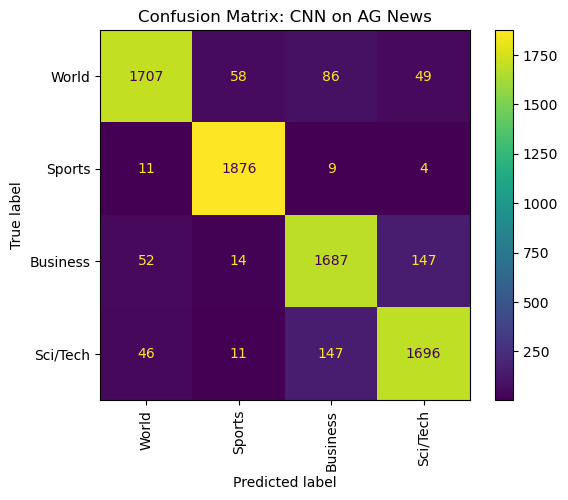

In [25]:
target_names = ["World", "Sports", "Business", "Sci/Tech"]

cnn_test = run_1_cnn_metrics[0]
cnn_hist = run_1_cnn_metrics[1]

print("\nCNN Classification Report")
print(classification_report(cnn_test["y_true"], cnn_test["y_pred"], target_names=target_names))

cm_cnn = confusion_matrix(cnn_test["y_true"], cnn_test["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: CNN on AG News")
plt.show()

### DistilBERT - 100% data; both title and description

Transformer Accuracy: 0.9407894736842105
              precision    recall  f1-score   support

       World       0.97      0.93      0.95      1900
      Sports       0.98      0.99      0.99      1900
    Business       0.92      0.91      0.91      1900
    Sci/Tech       0.90      0.93      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



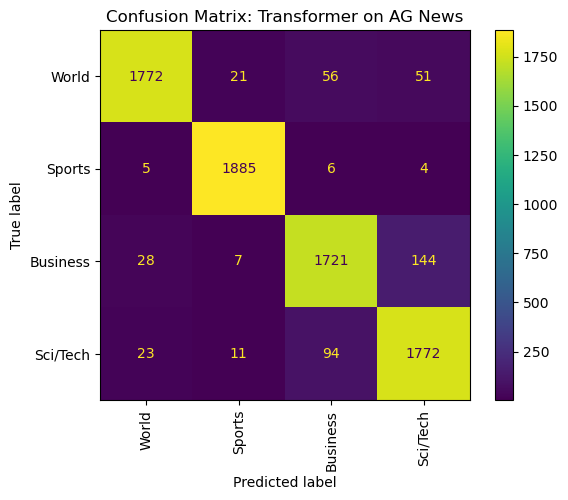

In [28]:
print("Transformer Accuracy:", accuracy_score(run_1_bert_y_true, run_1_bert_y_pred))
cm_tf = confusion_matrix(run_1_bert_y_true, run_1_bert_y_pred)
print(classification_report(run_1_bert_y_true, run_1_bert_y_pred, target_names=target_names))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tf, display_labels=target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: Transformer on AG News")
plt.show()

In [31]:
_, _, test_ds_hf = prepare_data(100, "both")

texts = [item["text"] for item in test_ds_hf]

y_true = run_1_bert_y_true
y_pred = run_1_bert_y_pred

true_labels = [target_names[i] for i in y_true]
pred_labels = [target_names[i] for i in y_pred]

min_len = min(len(test_ds_hf), len(y_true), len(y_pred))
texts = [item["text"] for item in test_ds_hf[:min_len]]
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

true_labels = [target_names[i] for i in y_true]
pred_labels = [target_names[i] for i in y_pred]

df_predictions = pd.DataFrame({
    "text": texts,
    "true_label": true_labels,
    "pred_label": pred_labels
})

errors = df_predictions[df_predictions["true_label"] != df_predictions["pred_label"]]

print(f"Total Errors: {len(errors)}")
print("Displaying first 20 misclassifications:")

pd.set_option("display.max_colwidth", 150)
display(errors.head(20))

Total Errors: 450
Displaying first 20 misclassifications:


,text,true_label,pred_label
23,"Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Str...",Sci/Tech,Business
24,"Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount s...",Sci/Tech,Business
36,Venezuela Prepares for Chavez Recall Vote Supporters and rivals warn of possible fraud; government says Chavez's defeat could produce turmoil in w...,World,Business
55,"Promoting a Shared Vision As Michael Kaleko kept running into people who were getting older and having more vision problems, he realized he could ...",Sci/Tech,Sports
79,Live: Olympics day four Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens.,World,Sports
83,"Intel to delay product aimed for high-definition TVs SAN FRANCISCO -- In the latest of a series of product delays, Intel Corp. has postponed the l...",Business,Sci/Tech
103,Surviving Biotech's Downturns Charly Travers offers advice on withstanding the volatility of the biotech sector.,Business,Sci/Tech
110,Yahoo! Ups Ante for Small Businesses Web giant Yahoo! is gambling that price cuts on its domain name registration and Web hosting products will ma...,Business,Sci/Tech
111,IBM Buys Two Danish Services Firms IBM said Tuesday it has acquired a pair of Danish IT services firms as part of its effort to broaden its presen...,Sci/Tech,Business
120,"Oil prices bubble to record high The price of oil has continued its sharp rise overnight, closing at a record high. The main contract in New York,...",World,Business


### DistilBERT - 100% data; title only

Transformer Accuracy - Title Only: 0.8981578947368422
              precision    recall  f1-score   support

       World       0.92      0.90      0.91      1900
      Sports       0.92      0.96      0.94      1900
    Business       0.88      0.84      0.86      1900
    Sci/Tech       0.86      0.89      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



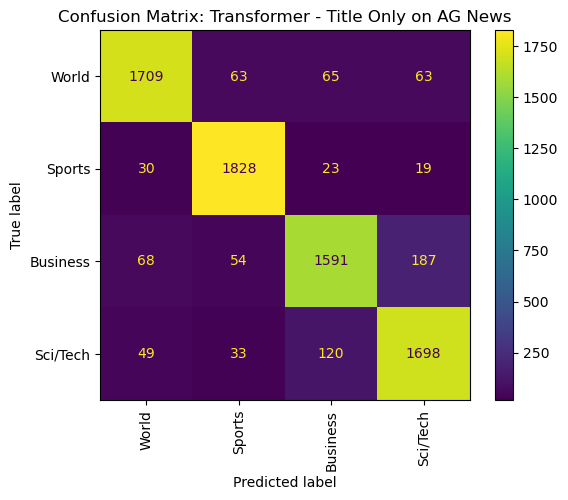

In [34]:
print("Transformer Accuracy - Title Only:", accuracy_score(run_2_bert_y_true, run_2_bert_y_pred))
cm_tf = confusion_matrix(run_2_bert_y_true, run_2_bert_y_pred)
print(classification_report(run_2_bert_y_true, run_2_bert_y_pred, target_names=target_names))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tf, display_labels=target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: Transformer - Title Only on AG News")
plt.show()

### DistilBERT - 50% data; both title and description

Transformer Accuracy - 50% Training Data: 0.930921052631579
              precision    recall  f1-score   support

       World       0.96      0.93      0.94      1900
      Sports       0.98      0.99      0.98      1900
    Business       0.91      0.87      0.89      1900
    Sci/Tech       0.87      0.93      0.90      1900

    accuracy                           0.93      7600
   macro avg       0.93      0.93      0.93      7600
weighted avg       0.93      0.93      0.93      7600



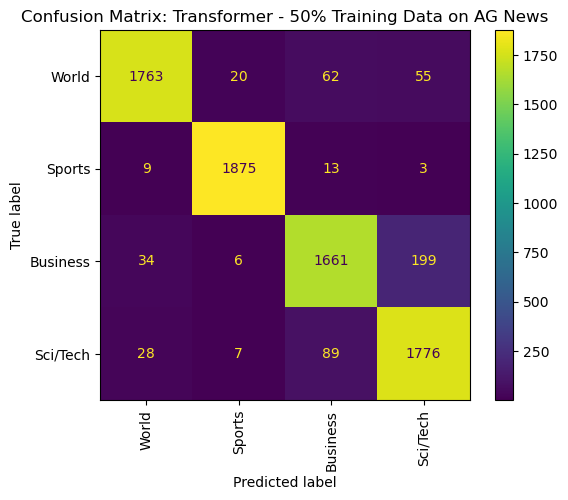

In [37]:
print("Transformer Accuracy - 50% Training Data:", accuracy_score(run_3_bert_y_true, run_3_bert_y_pred))
cm_tf = confusion_matrix(run_3_bert_y_true, run_3_bert_y_pred)
print(classification_report(run_3_bert_y_true, run_3_bert_y_pred, target_names=target_names))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tf, display_labels=target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: Transformer - 50% Training Data on AG News")
plt.show()

### DistilBERT - 25% data; both title and description

Transformer Accuracy - 25% Training Data: 0.9182894736842105
              precision    recall  f1-score   support

       World       0.95      0.92      0.93      1900
      Sports       0.97      0.98      0.98      1900
    Business       0.92      0.83      0.87      1900
    Sci/Tech       0.84      0.94      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



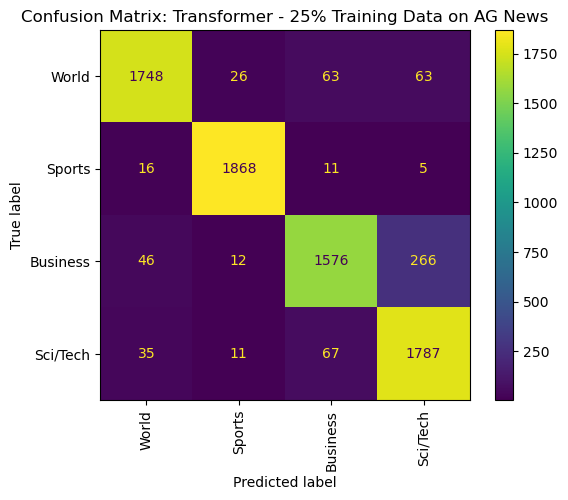

In [40]:
print("Transformer Accuracy - 25% Training Data:", accuracy_score(run_4_bert_y_true, run_4_bert_y_pred))
cm_tf = confusion_matrix(run_4_bert_y_true, run_4_bert_y_pred)
print(classification_report(run_4_bert_y_true, run_4_bert_y_pred, target_names=target_names))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tf, display_labels=target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: Transformer - 25% Training Data on AG News")
plt.show()